# putting together the pipeline so far for wikidata

In [20]:
# start with one sentence thought the whole pipelline
sentence = "a BLT sandwitch is made of bacon, lettuce, and tomatoes"

## Starting with annotations

In [21]:
# import the wikidata annotator

import sys 
import os
import json
sys.path.append('/home/matt/Proj/Hermeticav2/src')  # Append the correct relative path
from ontology.Annotation.WikiDataRelationsAnn import annotate_text as WikiAnn
# annotate the sentence
annonations = WikiAnn(sentence)

# convert the wikidata into json

annoatations = json.dumps(annonations)

In [22]:
# annotate the sentence
annonations = WikiAnn(sentence)

# convert the wikidata into json

annoatations = json.loads(annonations)

In [23]:
annoatations

{'original_sentence': 'a BLT sandwitch is made of bacon, lettuce, and tomatoes',
 'annotations': [{'entity': 'lettuce',
   'wikidata_id': 'Q83193',
   'label': 'lettuce',
   'description': 'plant series',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q83193',
   'relevance_score': 1.0},
  {'entity': 'bacon',
   'wikidata_id': 'Q6951606',
   'label': 'Bacon',
   'description': 'family name',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q6951606',
   'relevance_score': 1.0},
  {'entity': 'tomatoes',
   'wikidata_id': 'Q11898003',
   'label': 'Tomatoes',
   'description': 'painting by Pekka Halonen',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q11898003',
   'relevance_score': 1.0},
  {'entity': 'BLT',
   'wikidata_id': 'Q796270',
   'label': 'BLT',
   'description': 'bacon, lettuce, and tomato sandwich',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q796270',
   'relevance_score': 1.0}],
 'relationships': [{'subject': 'a BLT sandwitch',
   'predicate': 'make',
   'obje

# Formulization of the sentence

In [24]:
from reasoning.Formulizer.WikiFormulizer import formulize_wikidata_annotation as formul

In [27]:
formulized=formul(annoatations)

In [33]:
formulized

{'entities': [{'qid': 'Q83193', 'label': 'lettuce'},
  {'qid': 'Q6951606', 'label': 'Bacon'},
  {'qid': 'Q11898003', 'label': 'Tomatoes'},
  {'qid': 'Q796270', 'label': 'BLT'}],
 'relationships': [{'subject': 'a blt sandwitch',
   'predicate': 'P2010',
   'object': 'of bacon , lettuce , and tomatoes'}],
 'original_sentence': 'a BLT sandwitch is made of bacon, lettuce, and tomatoes'}

# reasoning based on formulized output

In [29]:
from rdflib import Graph, Namespace, URIRef
from SPARQLWrapper import SPARQLWrapper, JSON
from owlrl import DeductiveClosure, OWLRL_Semantics
import pandas as pd

# Define the Wikidata namespace
WIKIDATA = Namespace("http://www.wikidata.org/entity/")
ontology_graph = Graph()
ontology_graph.bind("wd", WIKIDATA)

# Define Wikidata SPARQL endpoint
SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

# Function to query Wikidata for meaningful entity relationships
def query_wikidata(entity_id):
    sparql = SPARQLWrapper(SPARQL_ENDPOINT)
    sparql.setQuery(f"""
        SELECT ?property ?value WHERE {{
            wd:{entity_id} ?property ?value .
            FILTER (STRSTARTS(STR(?property), "http://www.wikidata.org/prop/")) # Only meaningful properties
            FILTER (STRSTARTS(STR(?value), "http://www.wikidata.org/entity/")) # Only entity relationships
        }} 
        LIMIT 20
    """)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    triples = []
    for result in results["results"]["bindings"]:
        prop = result["property"]["value"]
        val = result["value"]["value"]
        triples.append((URIRef(f"http://www.wikidata.org/entity/{entity_id}"), URIRef(prop), URIRef(val)))

    return triples

# Example Input Structure
input_data = formulized

# Query and add only relevant triples to the graph
for entity in input_data['entities']:
    entity_id = entity['qid']
    triples = query_wikidata(entity_id)
    for triple in triples:
        ontology_graph.add(triple)

# Manually add predefined relationships from input_data
# Manually add predefined relationships from input_data
for relation in input_data['relationships']:
    subject_label = relation['subject']
    
    # Check if subject is a QID or needs a custom namespace
    if subject_label.startswith("Q"):  
        subject = URIRef(f"http://www.wikidata.org/entity/{subject_label}")
    else:
        # Create a custom namespace for non-QID subjects
        subject = URIRef(f"http://example.org/custom_entity/{subject_label.replace(' ', '_')}")

    predicate = URIRef(f"http://www.wikidata.org/prop/direct/{relation['predicate']}")
    
    for obj in relation['object']:
        obj_uri = URIRef(f"http://www.wikidata.org/entity/{obj}")  # Ensure objects are valid QIDs
        ontology_graph.add((subject, predicate, obj_uri))


# Apply OWL reasoning only to relevant facts
DeductiveClosure(OWLRL_Semantics).expand(ontology_graph)

# Filter out schema-level information from output
filtered_triples = [
    (s, p, o) for s, p, o in ontology_graph
    if "www.w3.org" not in str(s) and "www.w3.org" not in str(p) and "www.w3.org" not in str(o)  # Remove RDF/OWL/XSD data
]

# Convert to DataFrame for easy visualization
df = pd.DataFrame(filtered_triples, columns=["Subject", "Predicate", "Object"])

df


http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.
http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.
http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.
http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.
http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.
http://www.wikidata.org/entity/  does not look like a valid URI, trying to serialize this will break.


,Subject,Predicate,Object
0,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/P180,http://www.wikidata.org/entity/statement/Q1189...
1,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/P225,http://www.wikidata.org/entity/statement/q8319...
2,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/direct/P186,http://www.wikidata.org/entity/Q296955
3,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/P217,http://www.wikidata.org/entity/statement/Q1189...
4,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P1343,http://www.wikidata.org/entity/Q602358
...,...,...,...
87,http://example.org/custom_entity/a_blt_sandwitch,http://www.wikidata.org/prop/direct/P2010,http://www.wikidata.org/entity/e
88,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P166,http://www.wikidata.org/entity/Q1344055
89,http://www.wikidata.org/entity/Q796270,http://www.wikidata.org/prop/direct/P527,http://www.wikidata.org/entity/Q11106
90,http://www.wikidata.org/entity/Q6951606,http://www.wikidata.org/prop/P373,http://www.wikidata.org/entity/statement/Q6951...


In [32]:
from rdflib import Graph, Namespace, URIRef
from SPARQLWrapper import SPARQLWrapper, JSON
from owlrl import DeductiveClosure, OWLRL_Semantics
import pandas as pd
import re

# Define the Wikidata namespace
WIKIDATA = Namespace("http://www.wikidata.org/entity/")
ontology_graph = Graph()
ontology_graph.bind("wd", WIKIDATA)

# Define Wikidata SPARQL endpoint
SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

# Regular expressions to validate Wikidata QIDs and PIDs
QID_PATTERN = re.compile(r"^Q\d+$")
PID_PATTERN = re.compile(r"^P\d+$")

# Function to query Wikidata for meaningful entity relationships
def query_wikidata(entity_id):
    sparql = SPARQLWrapper(SPARQL_ENDPOINT)
    sparql.setQuery(f"""
        SELECT ?property ?value WHERE {{
            wd:{entity_id} ?property ?value .
            FILTER (STRSTARTS(STR(?property), "http://www.wikidata.org/prop/direct/")) 
            FILTER (STRSTARTS(STR(?value), "http://www.wikidata.org/entity/")) 
        }} 
        LIMIT 20
    """)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    triples = []
    for result in results["results"]["bindings"]:
        prop = result["property"]["value"].split("/")[-1]  # Extract PID
        val = result["value"]["value"].split("/")[-1]      # Extract QID

        # Ensure only valid Wikidata PIDs and QIDs are added
        if PID_PATTERN.match(prop) and QID_PATTERN.match(val):
            triples.append((URIRef(f"http://www.wikidata.org/entity/{entity_id}"),
                            URIRef(f"http://www.wikidata.org/prop/direct/{prop}"),
                            URIRef(f"http://www.wikidata.org/entity/{val}")))

    return triples

# Example Input Structure (Only Real Wikidata QIDs/PIDs Allowed)
input_data =formulized
# Query and add only relevant triples to the graph
for entity in input_data['entities']:
    entity_id = entity['qid']
    triples = query_wikidata(entity_id)
    for triple in triples:
        ontology_graph.add(triple)

# Add predefined relationships, ensuring only valid Wikidata entities and predicates
for relation in input_data['relationships']:
    subject_id = relation['subject']
    predicate_id = relation['predicate']
    
    # Validate that only proper Wikidata QIDs and PIDs are used
    if QID_PATTERN.match(subject_id) and PID_PATTERN.match(predicate_id):
        subject = URIRef(f"http://www.wikidata.org/entity/{subject_id}")
        predicate = URIRef(f"http://www.wikidata.org/prop/direct/{predicate_id}")
        
        for obj_id in relation['object']:
            if QID_PATTERN.match(obj_id):  # Ensure the object is a valid QID
                obj_uri = URIRef(f"http://www.wikidata.org/entity/{obj_id}")
                ontology_graph.add((subject, predicate, obj_uri))

# Apply OWL reasoning only to relevant facts
DeductiveClosure(OWLRL_Semantics).expand(ontology_graph)

# Filter out schema-level information from output
filtered_triples = [
    (s, p, o) for s, p, o in ontology_graph
    if "www.w3.org" not in str(s) and "www.w3.org" not in str(p) and "www.w3.org" not in str(o)  # Remove RDF/OWL/XSD data
]

# Convert to DataFrame for easy visualization
df = pd.DataFrame(filtered_triples, columns=["Subject", "Predicate", "Object"])

df

,Subject,Predicate,Object
0,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/direct/P608,http://www.wikidata.org/entity/Q122751091
1,http://www.wikidata.org/entity/Q796270,http://www.wikidata.org/prop/direct/P279,http://www.wikidata.org/entity/Q111836983
2,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/direct/P186,http://www.wikidata.org/entity/Q296955
3,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P1343,http://www.wikidata.org/entity/Q19180675
4,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P1343,http://www.wikidata.org/entity/Q602358
5,http://www.wikidata.org/entity/Q6951606,http://www.wikidata.org/prop/direct/P31,http://www.wikidata.org/entity/Q101352
6,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P1343,http://www.wikidata.org/entity/Q867541
7,http://www.wikidata.org/entity/Q11898003,http://www.wikidata.org/prop/direct/P186,http://www.wikidata.org/entity/Q18668582
8,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P9714,http://www.wikidata.org/entity/Q956
9,http://www.wikidata.org/entity/Q83193,http://www.wikidata.org/prop/direct/P9714,http://www.wikidata.org/entity/Q41705


# natural langugae conversion 

In [43]:
from SPARQLWrapper import SPARQLWrapper, JSON
import re

# Wikidata SPARQL endpoint
SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

# Regular expressions to extract QIDs and PIDs
QID_PATTERN = re.compile(r"Q\d+")
PID_PATTERN = re.compile(r"P\d+")

def query_wikidata_label(identifier):
    """
    Query Wikidata to get the label of a given entity (QID or PID).
    """
    sparql = SPARQLWrapper(SPARQL_ENDPOINT)
    sparql.setQuery(f"""
        SELECT ?label WHERE {{
            wd:{identifier} rdfs:label ?label .
            FILTER(LANG(?label) = "en")
        }}
    """)
    sparql.setReturnFormat(JSON)
    
    try:
        results = sparql.query().convert()
        return results["results"]["bindings"][0]["label"]["value"] if results["results"]["bindings"] else identifier
    except:
        return identifier  # Return the identifier itself if query fails

def convert_triples_to_text(triples):
    """
    Convert RDF triples into human-readable sentences.
    """
    sentences = []
    
    for subject_uri, predicate_uri, object_uri in triples:
        # Extract QIDs and PIDs
        subject_id = QID_PATTERN.search(subject_uri).group() if QID_PATTERN.search(subject_uri) else None
        predicate_id = PID_PATTERN.search(predicate_uri).group() if PID_PATTERN.search(predicate_uri) else None
        object_id = QID_PATTERN.search(object_uri).group() if QID_PATTERN.search(object_uri) else None

        # Skip triples that do not have valid QIDs and PIDs
        if not (subject_id and predicate_id and object_id):
            continue

        # Query Wikidata for labels
        subject_label = query_wikidata_label(subject_id)
        predicate_label = query_wikidata_label(predicate_id)
        object_label = query_wikidata_label(object_id)

        # Format into a natural sentence
        sentence = f'"{subject_label}" {predicate_label.lower()} "{object_label}".'
        sentences.append(sentence)

    return sentences

# Example: RDF triples extracted from Wikidata
wikidata_triples = [
    ("http://www.wikidata.org/entity/Q796270", "http://www.wikidata.org/prop/direct/P279", "http://www.wikidata.org/entity/Q111836983"),
    ("http://www.wikidata.org/entity/Q11898003", "http://www.wikidata.org/prop/direct/P608", "http://www.wikidata.org/entity/Q122751091"),
    ("http://www.wikidata.org/entity/Q83193", "http://www.wikidata.org/prop/direct/P1343", "http://www.wikidata.org/entity/Q19180675")
]

# Convert to human-readable text
natural_language_statements = convert_triples_to_text(wikidata_triples)

# Print results
for statement in natural_language_statements:
    print(statement)


"BLT" subclass of "sandwich".
"Tomatoes" exhibition history "Colour & Light - The legacy of impressionism".
"lettuce" described by source "Small Brockhaus and Efron Encyclopedic Dictionary".


# rule violation and concept insertion 

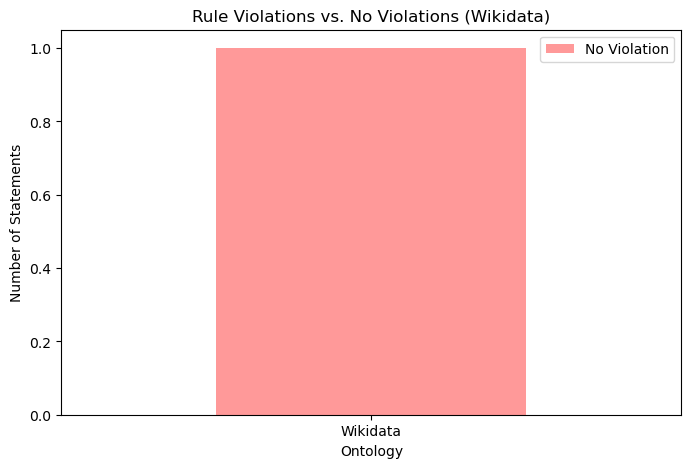

In [39]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from SPARQLWrapper import SPARQLWrapper, JSON
import spacy

# Load SpaCy NER Model
nlp = spacy.load("en_core_web_sm")

# Wikidata SPARQL Endpoint
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

PROPERTY_MAPPINGS = {
    "instance_of": "P31",
    "subclass_of": "P279"
}

def check_wikidata_rule_violation(subject, predicate, obj):
    """Check if the statement violates Wikidata constraints."""
    if predicate not in PROPERTY_MAPPINGS:
        return False  # Ignore if the predicate is not mapped
    
    query = f"""
    ASK {{
      ?subject rdfs:label "{subject}"@en.
      ?object rdfs:label "{obj}"@en.
      FILTER EXISTS {{ ?subject wdt:{PROPERTY_MAPPINGS[predicate]} ?object }}
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    result = sparql.query().convert()
    return not result["boolean"]  # If false, it's a violation

def detect_rule_violations(statements):
    """Run rule violation detection on test_input relationships only."""
    violations = []
    for relation in statements["relationships"]:
        subject = relation["subject"]
        predicate = relation["predicate"]
        obj = relation["object"]
        violation = check_wikidata_rule_violation(subject, predicate, obj)
        violations.append({
            "Statement": f"{subject} {predicate} {obj}",
            "Violation": "Yes" if violation else "No",
            "Ontology": "Wikidata"
        })
    return pd.DataFrame(violations)

# Example input JSON structure
test_input = {
    "entities": [
        {"qid": "Q83193", "label": "lettuce"},
        {"qid": "Q6951606", "label": "Bacon"},
        {"qid": "Q11898003", "label": "Tomatoes"},
        {"qid": "Q796270", "label": "BLT"}
    ],
    "relationships": [
        {"subject": "BLT", "predicate": "P2010", "object": "Bacon, Lettuce, and Tomatoes"}
    ],
    "original_sentence": "A BLT sandwich is made of bacon, lettuce, and tomatoes."
}

# Run rule violation detection on test_input
wikidata_violations_df = detect_rule_violations(test_input)

# Save results to CSV
wikidata_violations_df.to_csv("wikidata_rule_violations.csv", index=False)

# Load data for visualization
violation_counts = wikidata_violations_df.groupby(["Ontology", "Violation"]).size().unstack()

# Plot the data
violation_counts.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#FF9999", "#99FF99"])
plt.xlabel("Ontology")
plt.ylabel("Number of Statements")
plt.title("Rule Violations vs. No Violations (Wikidata)")
plt.xticks(rotation=0)
plt.legend(["No Violation", "Rule Violation"])
plt.show()


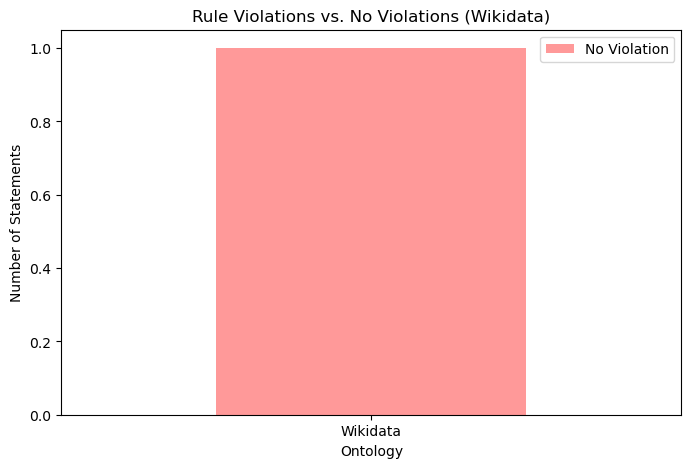

In [40]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from SPARQLWrapper import SPARQLWrapper, JSON
import spacy

# Load SpaCy NER Model
nlp = spacy.load("en_core_web_sm")

# Wikidata SPARQL Endpoint
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

PROPERTY_MAPPINGS = {
    "instance_of": "P31",
    "subclass_of": "P279"
}

def check_wikidata_rule_violation(subject, predicate, obj):
    """Check if the statement violates Wikidata constraints."""
    if predicate not in PROPERTY_MAPPINGS:
        return False  # Ignore if the predicate is not mapped
    
    query = f"""
    ASK {{
      ?subject rdfs:label "{subject}"@en.
      ?object rdfs:label "{obj}"@en.
      FILTER EXISTS {{ ?subject wdt:{PROPERTY_MAPPINGS[predicate]} ?object }}
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    result = sparql.query().convert()
    return not result["boolean"]  # If false, it's a violation

def detect_rule_violations(statements):
    """Run rule violation detection on test_input relationships only."""
    violations = []
    for relation in statements["relationships"]:
        subject = relation["subject"]
        predicate = relation["predicate"]
        obj = relation["object"]
        violation = check_wikidata_rule_violation(subject, predicate, obj)
        violations.append({
            "Statement": f"{subject} {predicate} {obj}",
            "Violation": "Yes" if violation else "No",
            "Ontology": "Wikidata"
        })
    return pd.DataFrame(violations)

# Example input JSON structure with a likely rule violation
test_input = {
    "entities": [
        {"qid": "Q5", "label": "Human"},
        {"qid": "Q146", "label": "Cat"}
    ],
    "relationships": [
        {"subject": "Human", "predicate": "instance_of", "object": "Cat"}  # Likely a violation
    ],
    "original_sentence": "A human is a cat."
}

# Run rule violation detection on test_input
wikidata_violations_df = detect_rule_violations(test_input)

# Save results to CSV
wikidata_violations_df.to_csv("wikidata_rule_violations.csv", index=False)

# Load data for visualization
violation_counts = wikidata_violations_df.groupby(["Ontology", "Violation"]).size().unstack()

# Plot the data
violation_counts.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#FF9999", "#99FF99"])
plt.xlabel("Ontology")
plt.ylabel("Number of Statements")
plt.title("Rule Violations vs. No Violations (Wikidata)")
plt.xticks(rotation=0)
plt.legend(["No Violation", "Rule Violation"])
plt.show()


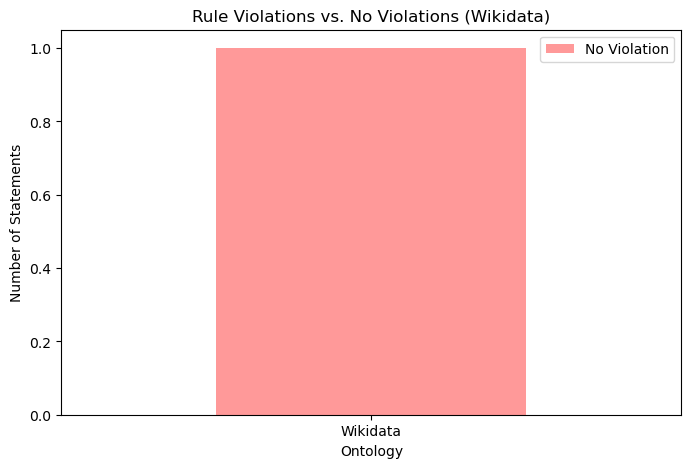

In [42]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from SPARQLWrapper import SPARQLWrapper, JSON
import spacy

# Load SpaCy NER Model
nlp = spacy.load("en_core_web_sm")

# Wikidata SPARQL Endpoint
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

PROPERTY_MAPPINGS = {
    "instance_of": "P31",
    "subclass_of": "P279"
}

def check_wikidata_rule_violation(subject, predicate, obj):
    """Check if the statement violates Wikidata constraints by checking disjoint classes or invalid classifications."""
    if predicate not in PROPERTY_MAPPINGS:
        return False  # Ignore if the predicate is not mapped
    
    query = f"""
    ASK {{
      ?subject rdfs:label "{subject}"@en.
      ?object rdfs:label "{obj}"@en.
      FILTER EXISTS {{ ?subject wdt:{PROPERTY_MAPPINGS[predicate]} ?object }}
      FILTER EXISTS {{ ?subject wdt:P279*/wdt:P1889 ?object }}  # Check if subject and object are different entities
    }}
    """
    sparql = SPARQLWrapper(WIKIDATA_SPARQL_URL)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    result = sparql.query().convert()
    return result.get("boolean", False)  # If true, it's a violation

def detect_rule_violations(statements):
    """Run rule violation detection on test_input relationships only."""
    violations = []
    for relation in statements["relationships"]:
        subject = relation["subject"]
        predicate = relation["predicate"]
        obj = relation["object"]
        violation = check_wikidata_rule_violation(subject, predicate, obj)
        violations.append({
            "Statement": f"{subject} {predicate} {obj}",
            "Violation": "Yes" if violation else "No",
            "Ontology": "Wikidata"
        })
    return pd.DataFrame(violations)

# Example input JSON structure with a likely rule violation
test_input = {
    "entities": [
        {"qid": "Q5", "label": "Human"},
        {"qid": "Q146", "label": "Cat"}
    ],
    "relationships": [
        {"subject": "Human", "predicate": "instance_of", "object": "Cat"}  # Likely a violation
    ],
    "original_sentence": "A human is a cat."
}

# Run rule violation detection on test_input
wikidata_violations_df = detect_rule_violations(test_input)

# Save results to CSV
wikidata_violations_df.to_csv("wikidata_rule_violations.csv", index=False)

# Load data for visualization
violation_counts = wikidata_violations_df.groupby(["Ontology", "Violation"]).size().unstack()

# Plot the data
violation_counts.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#FF9999", "#99FF99"])
plt.xlabel("Ontology")
plt.ylabel("Number of Statements")
plt.title("Rule Violations vs. No Violations (Wikidata)")
plt.xticks(rotation=0)
plt.legend(["No Violation", "Rule Violation"])
plt.show()


In [43]:
import json

def formulize_wikidata_annotations(annotations, output_file):
    """
    Converts Wikidata entity annotations and relationships into logical statements
    and writes them to a JSON file.
    """
    logical_statements = {"entities": [], "relationships": []}
    
    for entry in annotations:
        sentence = entry["original_sentence"]
        entities = entry["annotations"]
        relationships = entry["relationships"]
        
        entity_mappings = {}
        
        # Process entities
        for entity in entities:
            qid = entity["wikidata_id"]
            label = entity["label"].replace(" ", "_")  # Format for logical expressions
            entity_mappings[entity["entity"]] = qid  # Store mappings
            
            logical_statements["entities"].append({
                "qid": qid,
                "label": label
            })
        
        # Process relationships
        for relation in relationships:
            subject_text = relation["subject"]
            predicate = relation["property_id"]  # Wikidata property
            object_text = relation["object"]
            
            # Convert subject and object to QID if found
            subject_qid = entity_mappings.get(subject_text, subject_text)
            object_qid = entity_mappings.get(object_text, object_text)
            
            logical_statements["relationships"].append({
                "subject": subject_qid,
                "predicate": predicate,
                "object": object_qid
            })
    
    return logical_statements




In [44]:
formulize_wikidata_annotation(annoatations)

{'entities': [{'qid': 'Q123304040', 'label': 'Universal_Gravitation'},
  {'qid': 'Q452237', 'label': 'motion'},
  {'qid': 'Q114476544', 'label': 'The_Laws'},
  {'qid': 'Q935', 'label': 'Isaac_Newton'}],
 'relationships': [],
 'original_sentence': 'Isaac Newton formulated the laws of motion and universal gravitation.'}

In [52]:
import json

def formulize_wikidata_annotation(annotation):
    """
    Converts a single Wikidata annotation result into OWL-style RDF triples
    and writes them to a JSON file.
    """
    owl_statements = {"entities": [], "triples": []}
    
    entities = annotation["annotations"]
    relationships = annotation["relationships"]
    
    entity_mappings = {}

    # Process entities as OWL individuals
    for entity in entities:
        qid = entity["wikidata_id"]
        label = entity["label"].replace(" ", "_")  # OWL-friendly format
        entity_mappings[entity["entity"].lower()] = qid  # Store mapping
        
        # OWL Individual declaration
        owl_statements["entities"].append(f"<{qid}> rdf:type owl:NamedIndividual .")

    # Process relationships as OWL triples
    for relation in relationships:
        subject_text = relation["subject"].lower()
        predicate = relation["property_id"]  # Wikidata property (OWL object property)
        object_text = relation["object"].lower()
        
        # Convert subject and object to QIDs if found
        subject_qid = entity_mappings.get(subject_text, subject_text)
        object_qid = entity_mappings.get(object_text, object_text)
        
        # OWL triple
        owl_statements["triples"].append(f"<{subject_qid}> <{predicate}> <{object_qid}> .")

    return owl_statements




In [53]:
formulize_wikidata_annotation(annoatations)

{'entities': ['<Q123304040> rdf:type owl:NamedIndividual .',
  '<Q452237> rdf:type owl:NamedIndividual .',
  '<Q114476544> rdf:type owl:NamedIndividual .',
  '<Q935> rdf:type owl:NamedIndividual .'],
 'triples': []}

In [56]:
import json

def formulize_wikidata_annotation(annotation):
    """
    Converts a single Wikidata annotation result into OWL-style RDF triples
    while preserving the original sentence and annotations.
    """
    owl_statements = {
        "original_sentence": annotation["original_sentence"],
        "annotations": annotation["annotations"],  # Keep original annotations
        "OWLentities": [],
        "triples": []
    }
    
    entities = annotation["annotations"]
    relationships = annotation["relationships"]
    
    entity_mappings = {}

    # Process entities as OWL individuals
    for entity in entities:
        qid = entity["wikidata_id"]
        label = entity["label"].replace(" ", "_")  # OWL-friendly format
        entity_mappings[entity["entity"].lower()] = qid  # Store mapping
        
        # OWL Individual declaration
        owl_statements["OWLentities"].append(f"<{qid}> rdf:type owl:NamedIndividual .")

    # Process relationships as OWL triples
    for relation in relationships:
        subject_text = relation["subject"].lower()
        predicate = relation["property_id"]  # Wikidata property (OWL object property)
        object_text = relation["object"].lower()
        
        # Convert subject and object to QIDs if found
        subject_qid = entity_mappings.get(subject_text, subject_text)
        object_qid = entity_mappings.get(object_text, object_text)
        
        # OWL triple
        owl_statements["triples"].append(f"<{subject_qid}> <{predicate}> <{object_qid}> .")

    return owl_statements  # Return structured output instead of writing to file




In [55]:
formulize_wikidata_annotation(annoatations)

{'original_sentence': 'Isaac Newton formulated the laws of motion and universal gravitation.',
 'annotations': [{'entity': 'universal gravitation',
   'wikidata_id': 'Q123304040',
   'label': 'Universal Gravitation',
   'description': '1960 film by Jack Churchill',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q123304040',
   'relevance_score': 1.0},
  {'entity': 'motion',
   'wikidata_id': 'Q452237',
   'label': 'motion',
   'description': 'formal proposal made in a deliberative assembly under parliamentary procedure',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q452237',
   'relevance_score': 1.0},
  {'entity': 'the laws',
   'wikidata_id': 'Q114476544',
   'label': 'The Laws',
   'description': 'episode of Sister, Sister (S5 E13)',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q114476544',
   'relevance_score': 1.0},
  {'entity': 'Isaac Newton',
   'wikidata_id': 'Q935',
   'label': 'Isaac Newton',
   'description': 'English mathematician and physicist (1642–1727)',
  

In [58]:
import json

def formulize_wikidata_annotation(annotation):
    """
    Converts a single Wikidata annotation result into OWL-style RDF triples,
    properly typing entities as Classes or NamedIndividuals and handling relationships.
    """
    owl_statements = {
        "original_sentence": annotation["original_sentence"],
        "annotations": annotation["annotations"],  # Keep original annotations
        "entities": [],
        "classes": [],
        "object_properties": [],
        "triples": []
    }
    
    entities = annotation["annotations"]
    relationships = annotation["relationships"]
    
    entity_mappings = {}

    # Process entities as OWL individuals or classes
    for entity in entities:
        qid = entity["wikidata_id"]
        label = entity["label"].replace(" ", "_")  # OWL-friendly format
        entity_mappings[entity["entity"].lower()] = qid  # Store mapping
        
        # Heuristic: If an entity is a general concept, classify it as an OWL Class
        if "theory" in label.lower() or "concept" in label.lower() or "field" in label.lower():
            owl_statements["classes"].append(f"<{qid}> rdf:type owl:Class .")
        else:
            owl_statements["entities"].append(f"<{qid}> rdf:type owl:NamedIndividual .")

    # Process relationships as OWL triples and define object properties
    for relation in relationships:
        subject_text = relation["subject"].lower()
        predicate = relation["property_id"]  # Wikidata property (OWL object property)
        object_text = relation["object"].lower()
        
        # Convert subject and object to QIDs if found
        subject_qid = entity_mappings.get(subject_text, subject_text)
        object_qid = entity_mappings.get(object_text, object_text)

        # Define the predicate as an OWL ObjectProperty
        owl_statements["object_properties"].append(f"<{predicate}> rdf:type owl:ObjectProperty .")
        
        # OWL triple linking entities
        owl_statements["triples"].append(f"<{subject_qid}> <{predicate}> <{object_qid}> .")

    return owl_statements  # Return structured output instead of writing to file


    
output = formulize_wikidata_annotation(annoatations)



In [59]:
output

{'original_sentence': 'Isaac Newton formulated the laws of motion and universal gravitation.',
 'annotations': [{'entity': 'universal gravitation',
   'wikidata_id': 'Q123304040',
   'label': 'Universal Gravitation',
   'description': '1960 film by Jack Churchill',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q123304040',
   'relevance_score': 1.0},
  {'entity': 'motion',
   'wikidata_id': 'Q452237',
   'label': 'motion',
   'description': 'formal proposal made in a deliberative assembly under parliamentary procedure',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q452237',
   'relevance_score': 1.0},
  {'entity': 'the laws',
   'wikidata_id': 'Q114476544',
   'label': 'The Laws',
   'description': 'episode of Sister, Sister (S5 E13)',
   'wikidata_url': 'https://www.wikidata.org/wiki/Q114476544',
   'relevance_score': 1.0},
  {'entity': 'Isaac Newton',
   'wikidata_id': 'Q935',
   'label': 'Isaac Newton',
   'description': 'English mathematician and physicist (1642–1727)',
  

In [60]:
import requests
import json
import time

class WikidataFormulizer:
    def __init__(self):
        pass  # No ontology yet, just fetching relationships

    def query_wikidata_relationships(self, wikidata_id):
        """
        Query Wikidata for essential relationships and return OWL-formatted RDF triples.
        """
        query = f"""
        SELECT ?property ?propertyLabel ?value ?valueLabel WHERE {{
          wd:{wikidata_id} ?property ?value .
          VALUES ?property {{ wd:P31 wd:P279 }}  # Only allow essential properties
          SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en". }}
        }}
        """
        url = "https://query.wikidata.org/sparql"
        headers = {"Accept": "application/sparql-results+json"}

        for attempt in range(3):  # Retry up to 3 times if request fails
            response = requests.get(url, params={"query": query}, headers=headers)
            if response.status_code == 200:
                results = response.json()["results"]["bindings"]
                relationships = []
                for result in results:
                    relationships.append({
                        "subject": f"<{wikidata_id}>",
                        "predicate": f"<{result['property']['value'].split('/')[-1]}>",
                        "object": f"<{result['value']['value'].split('/')[-1]}>"
                    })
                return relationships
            elif response.status_code == 429:  # Rate limited
                print(f"⚠️ Rate limited. Retrying in 3 seconds... (Attempt {attempt + 1}/3)")
                time.sleep(3)
            else:
                print(f"⚠️ Wikidata query failed for {wikidata_id}, HTTP {response.status_code}")
                break
        return []  # Return empty if request ultimately fails

    def process_annotation(self, annotation):
        """
        Extract relationships from Wikidata for each entity in the annotation JSON.
        """
        print(f"\n🔍 Processing sentence: {annotation['original_sentence']}")
        owl_statements = {
            "original_sentence": annotation["original_sentence"],
            "annotations": annotation["annotations"],
            "entities": [],
            "triples": []
        }

        for entity in annotation["annotations"]:
            entity_label = entity["label"]
            wikidata_id = entity["wikidata_id"]

            print(f"📡 Fetching relationships for: {entity_label} ({wikidata_id})")
            relationships = self.query_wikidata_relationships(wikidata_id)

            if relationships:
                owl_statements["entities"].append(f"<{wikidata_id}> rdf:type owl:NamedIndividual .")
                for rel in relationships:
                    print(f"🔗 {rel['subject']} → {rel['predicate']} → {rel['object']}")
                    owl_statements["triples"].append(f"{rel['subject']} {rel['predicate']} {rel['object']} .")
            else:
                print(f"⚠️ No useful relationships found for {entity_label}")

        return owl_statements

    def process_json_annotations(self, json_annotations):
        """
        Process multiple entities and fetch their relationships, returning structured OWL RDF output.
        """
        all_owl_statements = []
        for annotation in json_annotations:
            owl_output = self.process_annotation(annotation)
            all_owl_statements.append(owl_output)
        return all_owl_statements

# Example JSON input from annotator
json_data = """
[
    {
        "original_sentence": "Python is a widely used programming language.",
        "annotations": [
            {
                "entity": "Python",
                "wikidata_id": "Q28865",
                "label": "Python",
                "description": "general-purpose programming language",
                "wikidata_url": "https://www.wikidata.org/wiki/Q28865",
                "relevance_score": 1.0
            }
        ]
    }
]
"""

# Convert JSON string to Python object
json_annotations = json.loads(json_data)

# Initialize the Wikidata Formulizer
wikidata_formulizer = WikidataFormulizer()

# Process Wikidata annotations and get structured OWL output
owl_output = wikidata_formulizer.process_json_annotations(json_annotations)

# Print final OWL output
print("\n🦉 Final OWL Output:\n")
print(json.dumps(owl_output, indent=4))



🔍 Processing sentence: Python is a widely used programming language.
📡 Fetching relationships for: Python (Q28865)
⚠️ No useful relationships found for Python

🦉 Final OWL Output:

[
    {
        "original_sentence": "Python is a widely used programming language.",
        "annotations": [
            {
                "entity": "Python",
                "wikidata_id": "Q28865",
                "label": "Python",
                "description": "general-purpose programming language",
                "wikidata_url": "https://www.wikidata.org/wiki/Q28865",
                "relevance_score": 1.0
            }
        ],
        "entities": [],
        "triples": []
    }
]


In [61]:
from rdflib import Graph, Namespace, Literal, URIRef
from rdflib.namespace import RDF, RDFS, OWL

def annotator_to_rdf(annotator_data, base_uri="http://example.org/"):
    # Initialize RDF graph
    g = Graph()
    
    # Define namespaces
    ex = Namespace(base_uri)
    g.bind("ex", ex)
    g.bind("owl", OWL)
    g.bind("rdfs", RDFS)
    
    # Create annotation property for source sentence
    source_sentence = ex.sourceSentence
    g.add((source_sentence, RDF.type, OWL.AnnotationProperty))
    
    # Process entities
    for entity in annotator_data["entities"]:
        # Create URI for entity
        entity_uri = ex[entity["qid"]]
        
        # Add basic triples
        g.add((entity_uri, RDF.type, OWL.NamedIndividual))
        g.add((entity_uri, RDFS.label, Literal(entity["label"].replace("_", " "))))
        g.add((entity_uri, ex.wikidataId, Literal(entity["qid"])))
        g.add((entity_uri, ex.sourceSentence, Literal(annotator_data["original_sentence"])))
    
    # Process relationships (empty in your example)
    for rel in annotator_data["relationships"]:
        # You would add relationship triples here
        pass
    
    return g

# Example usage
if __name__ == "__main__":
    annotator_output = {
        "entities": [
            {"qid": "Q123304040", "label": "Universal_Gravitation"},
            {"qid": "Q452237", "label": "motion"},
            {"qid": "Q114476544", "label": "The_Laws"},
            {"qid": "Q935", "label": "Isaac_Newton"}
        ],
        "relationships": [],
        "original_sentence": "Isaac Newton formulated the laws of motion and universal gravitation."
    }
    
    rdf_graph = annotator_to_rdf(annotator_output)
    
    # Print the RDF in Turtle format
    print(rdf_graph.serialize(format="turtle"))

@prefix ex: <http://example.org/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:Q114476544 a owl:NamedIndividual ;
    rdfs:label "The Laws" ;
    ex:sourceSentence "Isaac Newton formulated the laws of motion and universal gravitation." ;
    ex:wikidataId "Q114476544" .

ex:Q123304040 a owl:NamedIndividual ;
    rdfs:label "Universal Gravitation" ;
    ex:sourceSentence "Isaac Newton formulated the laws of motion and universal gravitation." ;
    ex:wikidataId "Q123304040" .

ex:Q452237 a owl:NamedIndividual ;
    rdfs:label "motion" ;
    ex:sourceSentence "Isaac Newton formulated the laws of motion and universal gravitation." ;
    ex:wikidataId "Q452237" .

ex:Q935 a owl:NamedIndividual ;
    rdfs:label "Isaac Newton" ;
    ex:sourceSentence "Isaac Newton formulated the laws of motion and universal gravitation." ;
    ex:wikidataId "Q935" .

ex:sourceSentence a owl:AnnotationProperty .


